Processing BRCA-1 ...
Processing BRCA-2 ...
Processing LUSC ...
Processing LAML ...
Processing NCI60-1 ...
Processing NCI60-2 ...
Processing NCI60-3 ...
Processing METSIM ...


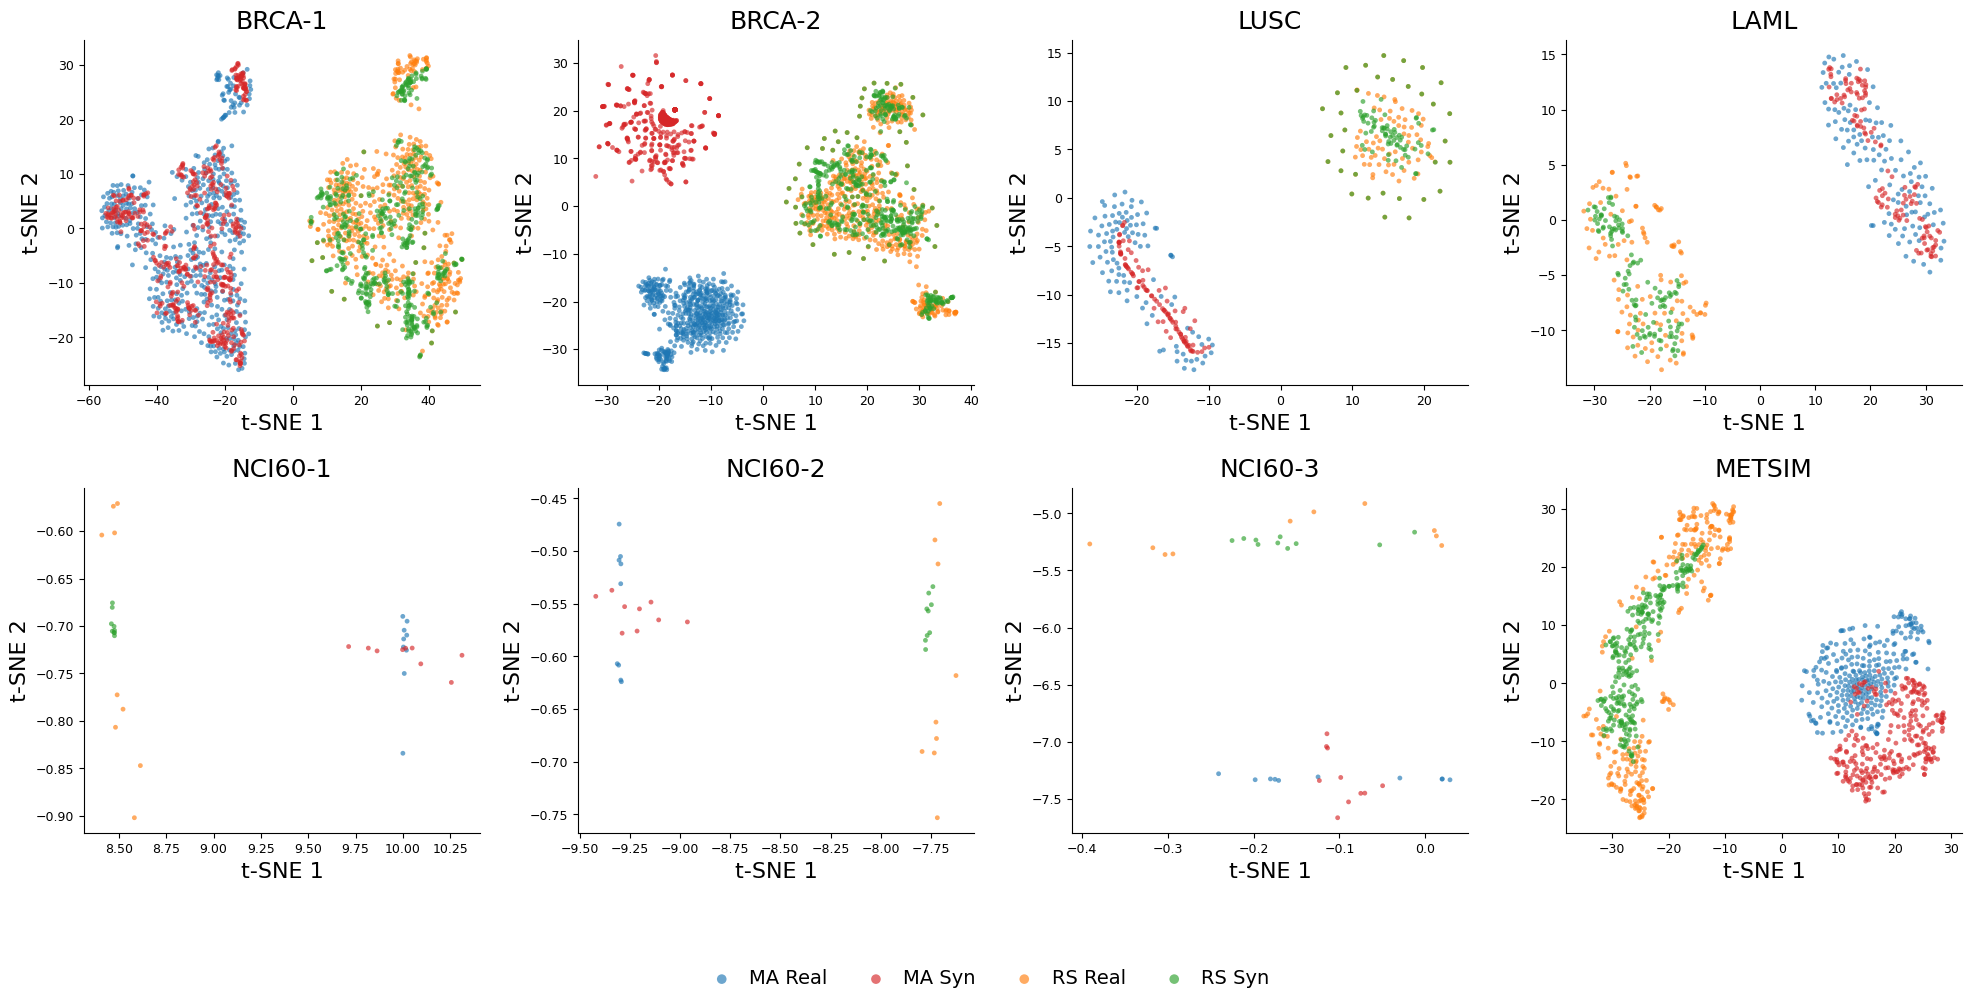

In [41]:
import os
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# -----------------------------
# Global plotting style
# -----------------------------
plt.rcParams.update({
    'font.size': 16,          # base (important)
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 14
})

# -----------------------------
# Dataset folders
# -----------------------------
base_dir = "/main/projects/GANomics/dashboard/backend/results_old/2_SyncData"

dataset_dirs = {
    "BRCA-1": os.path.join(base_dir, "BRCA-1_50_0", "test"),
    "BRCA-2": os.path.join(base_dir, "BRCA-2_50_0", "test"),
    "LUSC":   os.path.join(base_dir, "LUSC_50_0", "test"),
    "LAML":   os.path.join(base_dir, "LAML_50_0", "test"),
    "NCI60-1": os.path.join(base_dir, "NCI60-1_50_0", "test"),
    "NCI60-2": os.path.join(base_dir, "NCI60-2_50_0", "test"),
    "NCI60-3": os.path.join(base_dir, "NCI60-3_50_0", "test"),
    "METSIM": os.path.join("/main/projects/GANomics/dashboard/backend/results_ms/2_SyncData/METSIM_50_1", "test"),
}

# -----------------------------
# Colors
# -----------------------------
colors = {
    'MA Real': '#1f77b4',   # blue
    'MA Syn':  '#d62728',   # red
    'RS Real': '#ff7f0e',   # orange
    'RS Syn':  '#2ca02c'    # green
}

# -----------------------------
# Helper function
# -----------------------------
def load_dataset(folder):
    df_ma_real = pd.read_csv(os.path.join(folder, "microarray_real.csv"), index_col=0)
    df_ma_fake = pd.read_csv(os.path.join(folder, "microarray_fake.csv"), index_col=0)
    df_rs_real = pd.read_csv(os.path.join(folder, "rnaseq_real.csv"), index_col=0)
    df_rs_fake = pd.read_csv(os.path.join(folder, "rnaseq_fake.csv"), index_col=0)
    return df_ma_real, df_ma_fake, df_rs_real, df_rs_fake

def compute_tsne(df_ma_real, df_ma_fake, df_rs_real, df_rs_fake,
                 perplexity=30, random_state=42):
    combined_data = np.vstack([
        df_ma_real.values,
        df_ma_fake.values,
        df_rs_real.values,
        df_rs_fake.values
    ])

    labels = np.array(
        ['MA Real'] * len(df_ma_real) +
        ['MA Syn']  * len(df_ma_fake) +
        ['RS Real'] * len(df_rs_real) +
        ['RS Syn']  * len(df_rs_fake)
    )

    scaled_data = StandardScaler().fit_transform(combined_data)

    tsne = TSNE(
        n_components=2,
        random_state=random_state,
        perplexity=perplexity,
        max_iter=1000,
        init='pca',
        learning_rate='auto'
    )
    tsne_results = tsne.fit_transform(scaled_data)
    return tsne_results, labels

# -----------------------------
# Create 2x4 subplot figure
# -----------------------------
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

legend_handles = None
legend_labels = None

for i, (dataset_name, folder) in enumerate(dataset_dirs.items()):
    ax = axes[i]

    print(f"Processing {dataset_name} ...")

    df_ma_real, df_ma_fake, df_rs_real, df_rs_fake = load_dataset(folder)
    tsne_results, labels = compute_tsne(
        df_ma_real, df_ma_fake, df_rs_real, df_rs_fake,
        perplexity=30, random_state=42
    )

    for label, color in colors.items():
        mask = labels == label
        sc = ax.scatter(
            tsne_results[mask, 0],
            tsne_results[mask, 1],
            s=12,
            alpha=0.65,
            color=color,
            edgecolors='none',
            label=label
        )

    ax.set_title(dataset_name, pad=8)
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

    ax.grid(False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis='both', labelsize=9)

    # Save legend handles once
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

# ---- Shared legend (for whole figure) ----
fig.legend(
    handles=legend_handles,
    labels=legend_labels,
    loc='lower center',
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),  # slightly below figure
    markerscale=2,
    handletextpad=0.4,
    columnspacing=1.5
)

# Adjust layout to make room for legend
plt.tight_layout(rect=[0, 0.08, 1, 1])